In [18]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math

### Autocorrelation and statistical uncertainties

In [19]:
def compute_autocorrelation(data, t_sup):
    tmax = len(data)
    autocorr = np.empty(t_sup)
    
    avg_tot_2 = np.sum(data * data) / tmax
    avg_tot = np.sum(data) / tmax
    var_tot = avg_tot_2 - np.power(avg_tot, 2)
    
    for t in range(t_sup):
        dt = tmax - t
        num = np.sum(data[:dt]*data[t:])/dt - np.sum(data[:dt])*np.sum(data[t:])/(dt*dt)
        autocorr[t] = num / var_tot
    
    return autocorr

def error(L, data):
    N = int(len(data)//L) # // indica la divisione intera e ci metto int per assicurarmi ulteriormente di avere un intero
    averages = np.array([np.sum(data[i*L:(i+1)*L]) / L for i in range(N)])
    sum_averages = np.sum(averages) / N
    sum_averages2 = np.sum(averages * averages) / N

    return np.sqrt((sum_averages2-np.power(sum_averages,2))/(N-1))

[]

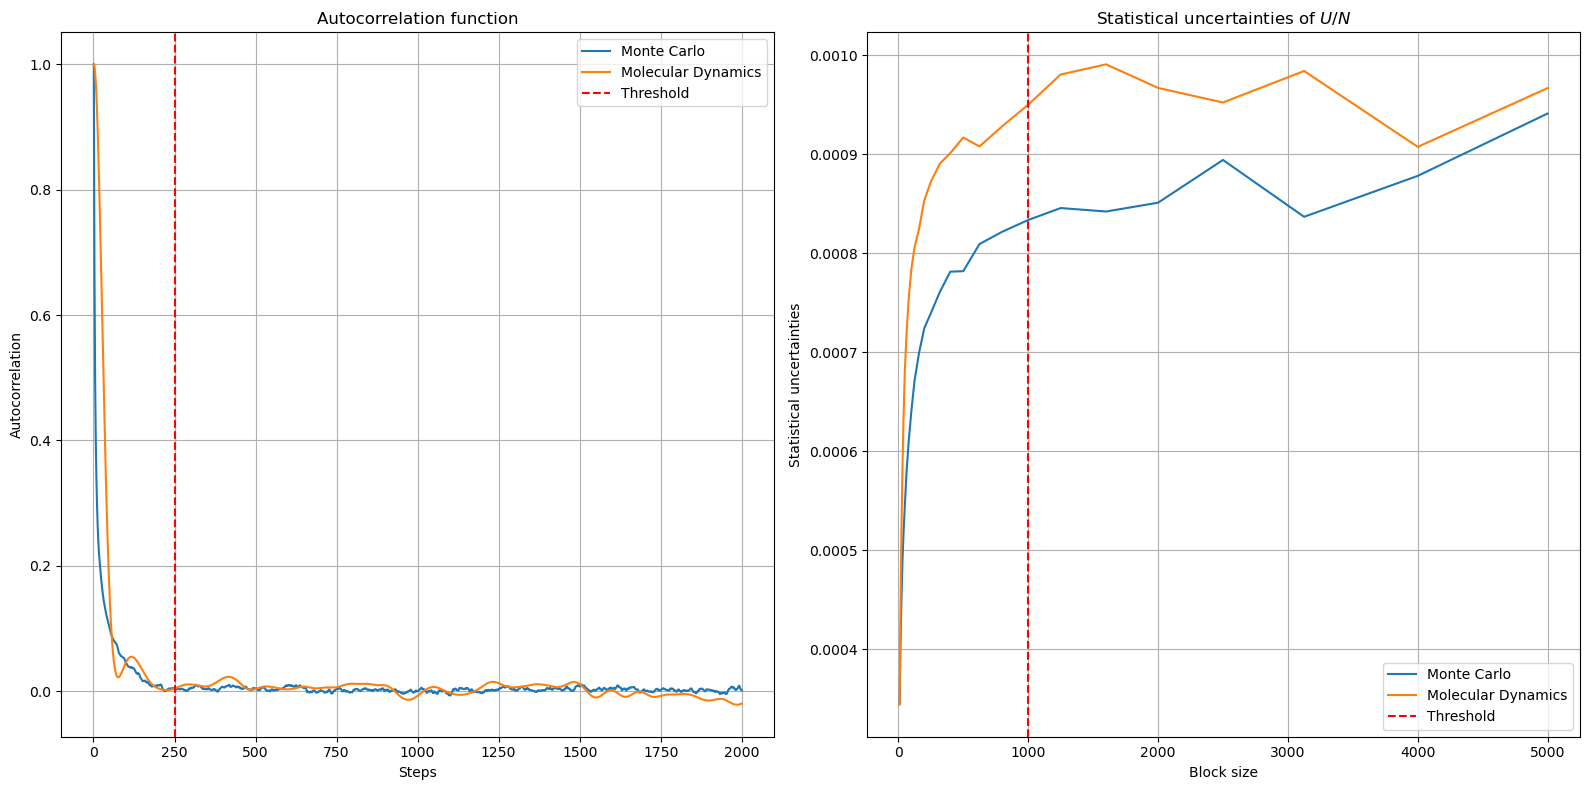

In [20]:
x, func_MC, error_MC = np.loadtxt("../OUTPUT/potential_energy_MC.dat", usecols=(0,1,3), skiprows=1, unpack='true')
autocorr_MC = compute_autocorrelation(func_MC, 5000)
func_MD, error_MD = np.loadtxt("../OUTPUT/potential_energy_MD.dat", usecols=(1,3), skiprows=1, unpack='true')
autocorr_MD = compute_autocorrelation(func_MD, 5000)

fig, axs = plt.subplots(1, 2, figsize=(16,8))

axs[0].plot(x[:2000], autocorr_MC[:2000], label="Monte Carlo")
axs[0].plot(x[:2000], autocorr_MD[:2000], label="Molecular Dynamics")
axs[0].set_xlabel("Steps")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_title("Autocorrelation function")
axs[0].axvline(x=250, linestyle='--', color='red', label='Threshold')
axs[0].legend()
axs[0].grid(True)

#Funzione che restituisce un array contenente tutti i divisori di 500000 da 10 fino a 5000
L = np.array( [n for n in range(10, 5001) if 5000000%n == 0] )

errors_MC = [error(int(i), func_MC) for i in L]
errors_MD = [error(int(i), func_MD) for i in L]

axs[1].plot(L, errors_MC, label="Monte Carlo")
axs[1].plot(L, errors_MD, label="Molecular Dynamics")
axs[1].set_xlabel("Block size")
axs[1].set_ylabel("Statistical uncertainties")
axs[1].set_title("Statistical uncertainties of $U/N$")
axs[1].axvline(x=1000, linestyle='--', color='red', label='Threshold')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.plot()


### Commenti
Per entrambe le simulazioni sono state condotte delle equilibrazioni di $4 \cdot 10^4$ steps. Nel caso di Dinamica Molecolare è stata impostata una temperatura iniziale $T = 1.95$ che durante l'equilibrazione è scesa a $T^* = 1.1405 \pm 0.0003$, abbastanza simile a quella utilizzata per la simulazione Monte Carlo. Per quest'ultima, è stato utilizzato un time step $dt = 0.1$ in modo che il tasso di accettazione fosse circa il $50\%$. Successivamente sono state condotte le simulazioni in esame con $5 \cdot 10^5$ blocchi da uno step ciascuno.

Dal primo grafico si può notare come l'autocorrelazione si assesti intorno allo 0 per valori maggiori o uguali di $\approx 250$ steps, implicando quindi un tempo di correlazione $\tau_c \approx 250$. Il numero di steps per blocco deve quindi essere $L \gg 250$ ed è compatibile con la stima di $L \geq 1000$ che otteniamo dal secondo grafico. Infatti da esso notiamo che la soglia oltre la quale l'incertezza comincia ad avere fluttuazioni è circa $1000$ steps (per blocco). Inoltre, queste fluttuazioni sono dovute al fatto che all'aumentare di $L$ diminuisce il numero $N$ di blocchi su cui mediare.